# 01 Data Exploration
EDA: California Property Close Price Prediction

### Set-Up Environment

In [15]:
# %pip install pandas
# %pip install matplotlib
import pandas as pd
# print("Pandas version:", pd.__version__)
import glob
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Load and Read Data
Dataset: Recent 6 Months of CRMLSSold files from /raw/California (202512, ... , 202605)

In [16]:
# Find the data files in the data folder and sort by name
data = sorted(glob.glob('../../data/CRMLSSold*.csv'))
print(data)

['../../data\\CRMLSSold202512.csv', '../../data\\CRMLSSold202601.csv', '../../data\\CRMLSSold202602.csv', '../../data\\CRMLSSold202603.csv', '../../data\\CRMLSSold202604.csv', '../../data\\CRMLSSold202605.csv']


### Read and filter the CSV files
Mapping requested task-doc variables to existing columns as found in the CRMLSSold*.csv files
- Bedrooms --> BedroomsTotal
- Bathrooms --> BathroomsTotalInteger
- LotSize --> LotSizeAcres

Per task doc, restrict to PropertyType = Residential and PropertySubType = SingleFamilyResidence.

In [17]:
all_csv = []
raw_total = 0

# Apply filters to all files
for file in data:
    #print(f"Processing file: {file}")
    csv = pd.read_csv(file, low_memory=False)
    raw_total += len(csv)

    # restrict analysis per task doc
    csv = csv[(csv['PropertyType'] == 'Residential') & (csv['PropertySubType'] == 'SingleFamilyResidence')].copy()

    all_csv.append(csv)

df = pd.concat(all_csv, ignore_index=True)

# Reverify total files read
print(f'Total files read: {len(all_csv)}')
# Rows before filtering
print(f'Total rows read pre-filter: {raw_total:,}')
print(f'Total rows read post-filter (restrictions): {len(df):,}')

Total files read: 6
Total rows read pre-filter: 124,404
Total rows read post-filter (restrictions): 61,727


## Dataset Overview
Previewing the whole dataset

In [18]:
display(df.head(10))
df.info()
# Summary statistics
df.describe()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,NaN,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN
1,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,NaN,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN
2,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,NaN,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,3100000.0,1150032869,vickie@realsmartgroup.com,...,NaN,8262.0,NaN,False,1.0,San Jose Unified,95124,NaN,8262.0,NaN
4,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,2900000.0,1150028403,vickie@realsmartgroup.com,...,NaN,9222.0,NaN,False,2.0,Other,95128,NaN,9222.0,NaN
5,OrangeCounty,OrangeCounty,"Vinyl,Wood",True,NaN,NaN,False,1099000.0,1150011437,evelyn@evelyntee.com,...,NaN,3478.0,2.0,False,2.0,Capistrano Unified,92692,584.0,3478.0,NaN
6,ContraCosta,ContraCosta,"Laminate,Tile,Wood",NaN,NaN,NaN,False,699999.0,1149985691,amyzellerhomes@gmail.com,...,NaN,7000.0,NaN,False,1.0,Mount Diablo,94519,NaN,7000.0,NaN
7,SouthwestRiversideCounty,SouthwestRiversideCounty,"Carpet,Tile,Wood",True,NaN,NaN,False,1140000.0,1149981970,ashley@theashleycooperteam.com,...,NaN,12197.0,1.0,False,4.0,Temecula Unified,92592,55.0,12197.0,NaN
8,ContraCosta,ContraCosta,SeeRemarks,NaN,NaN,NaN,False,914000.0,1149980380,erin@mckeonhomes.com,...,NaN,3051.0,NaN,False,2.0,NaN,94112,NaN,3051.0,NaN
9,Laguna,Laguna,"Carpet,Wood",True,NaN,NaN,False,2500000.0,1149973476,Heidi.cleveland@elliman.com,...,NaN,2825.0,1.0,False,1.0,Laguna Beach Unified,92651,0.0,2825.0,NaN


<class 'pandas.DataFrame'>
RangeIndex: 61727 entries, 0 to 61726
Data columns (total 78 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuyerAgentAOR                 58063 non-null  str    
 1   ListAgentAOR                  61709 non-null  str    
 2   Flooring                      39242 non-null  str    
 3   ViewYN                        56432 non-null  object 
 4   WaterfrontYN                  36 non-null     object 
 5   BasementYN                    1455 non-null   object 
 6   PoolPrivateYN                 56894 non-null  object 
 7   OriginalListPrice             61591 non-null  float64
 8   ListingKey                    61727 non-null  int64  
 9   ListAgentEmail                61596 non-null  str    
 10  CloseDate                     61727 non-null  str    
 11  ClosePrice                    61727 non-null  float64
 12  ListAgentFirstName            61355 non-null  str    
 13  ListAgentLas

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,6.159100e+04,6.172700e+04,6.172700e+04,61718.000000,61718.000000,61697.000000,6.172700e+04,61727.000000,0.0,0.0,...,0.0,445.000000,0.0,55234.000000,6.064900e+04,37653.000000,59374.000000,44111.000000,6.064600e+04,0.0
mean,1.339445e+06,1.146687e+09,1.340106e+06,34.708615,-118.560570,2055.552918,1.267892e+06,41.436130,NaN,NaN,...,NaN,56.276404,NaN,1.351468,1.940905e+04,2.264521,2.005196,111.463261,3.859489e+05,NaN
std,5.195236e+06,1.276873e+07,7.307629e+06,1.802984,3.253774,1037.243701,1.524326e+06,57.529263,NaN,NaN,...,NaN,225.966677,NaN,0.477433,2.052488e+05,1.447379,3.327872,368.761236,1.843401e+07,NaN
min,0.000000e+00,4.217759e+08,1.750000e+00,-22.863239,-124.175789,0.000000,8.000000e+03,-39.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.299000e+05,1.144826e+09,6.200000e+05,33.753896,-119.063627,1386.000000,6.244800e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.392000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.990000e+05,1.150713e+09,8.900000e+05,34.077919,-118.017017,1826.000000,8.900000e+05,19.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.023000e+03,3.000000,2.000000,0.000000,7.263500e+03,NaN
75%,1.445000e+06,1.153674e+09,1.425000e+06,34.695388,-117.250670,2455.000000,1.399900e+06,53.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,9.900000e+03,3.000000,2.000000,136.000000,1.045400e+04,NaN
max,7.250000e+08,1.171669e+09,7.960000e+08,43.784440,118.140030,23314.000000,6.500000e+07,2177.000000,NaN,NaN,...,NaN,2031.000000,NaN,2.000000,3.164242e+07,44.000000,600.000000,20712.000000,1.897474e+09,NaN


## Missing Data
Checking for missing values in the dataframe

            n_rows  n_close_prices  n_close_dates
ListingKey                                       
1107335546       2               1              2
1108963864       2               1              2
1118281460       2               1              2
1118859284       2               2              2
1125615193       2               1              2
1133703163       2               1              1
1135646820       2               1              2
1137564166       2               2              2
1138529088       2               1              2
1139401118       2               1              2
Total duplicated ListingKeys: 33
Total extra rows from duplicates: 33


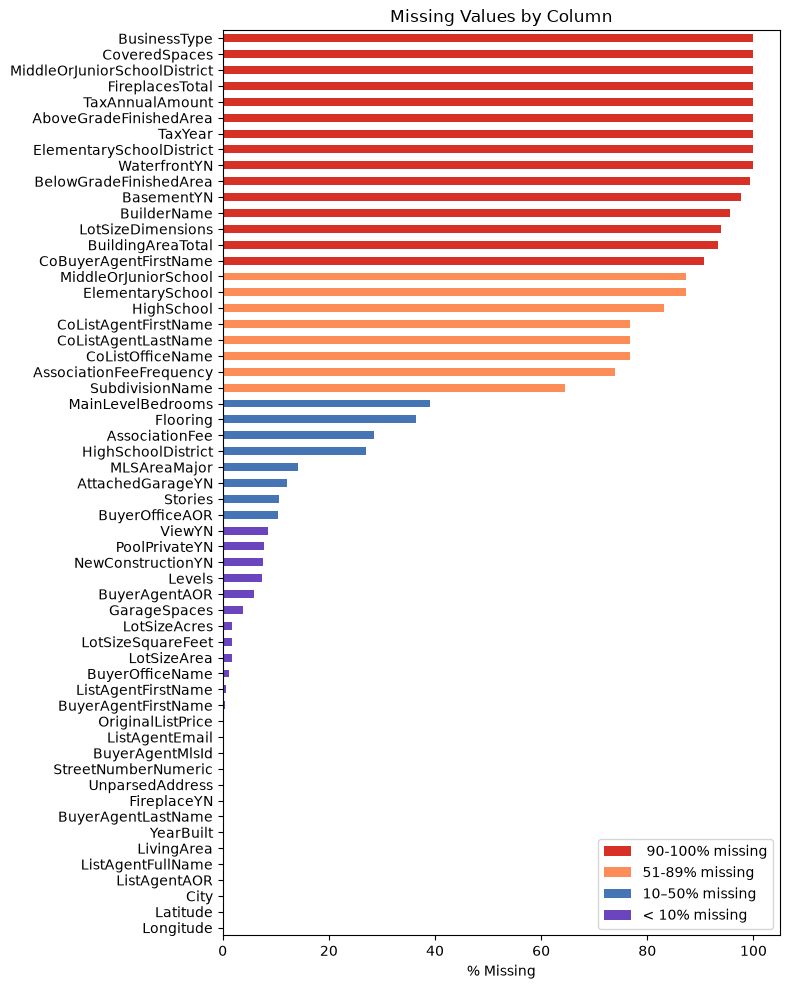

Columns 100% missing (8):
  BusinessType
  CoveredSpaces
  MiddleOrJuniorSchoolDistrict
  FireplacesTotal
  TaxAnnualAmount
  AboveGradeFinishedArea
  TaxYear
  ElementarySchoolDistrict


In [19]:
# Check for duplicates
dupe_keys = df[df['ListingKey'].duplicated(keep=False)]
dupe_summary = (
    dupe_keys.groupby('ListingKey')
    .agg(n_rows=('ListingKey', 'size'),
         n_close_prices=('ClosePrice', 'nunique'),
         n_close_dates=('CloseDate', 'nunique'))
    .sort_values('n_rows', ascending=False)
)
print(dupe_summary.head(10))
# Some ListingKeys appear in two of the six monthly files with the same ClosePrice but different CloseDate, this is likely a listing that was re-reported across month boundaries. 
# To be resolved during preprocessing.

print(f'Total duplicated ListingKeys: {len(dupe_summary)}')
print(f'Total extra rows from duplicates: {(dupe_summary["n_rows"] - 1).sum()}')



# percentage of missing values in each column
missing_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
missing_nonzero = missing_pct[missing_pct > 0]

colors = missing_nonzero.map(
    lambda x: '#d73027' if x >= 90 else '#fc8d59' if x > 50 else '#4575b4' if x > 10 else "#6a45be")

# Visualize missing values
plt.figure(figsize=(8, 10))
missing_nonzero.plot(kind='barh', color=colors)
plt.xlabel('% Missing')
plt.title('Missing Values by Column')
plt.gca().invert_yaxis()

legend_elements = [ 
    Patch(facecolor='#d73027', label=' 90-100% missing'),
    Patch(facecolor='#fc8d59', label='51-89% missing'),
    Patch(facecolor='#4575b4', label='10–50% missing'),
    Patch(facecolor='#6a45be', label='< 10% missing'),
]

plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

# Display columns completely missing (100%)
full_null = missing_pct[missing_pct == 100]
print(f'Columns 100% missing ({len(full_null)}):')
for col in full_null.index:
    print(f'  {col}')

## Focused Variables

Per task doc, exploring distributions of:
- ClosePrice (target variable)
- LivingArea
- Bedrooms → BedroomsTotal
- Bathrooms → BathroomsTotalInteger
- LotSize → LotSizeAcres

In [20]:
key_vars = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres']
key_df = df[key_vars].copy()

# Get outliers of the key variables
print(key_df.describe())

# Re-check for missing values in the key variables
print(key_df.isnull().sum())

         ClosePrice    LivingArea  BedroomsTotal  BathroomsTotalInteger  \
count  6.172700e+04  61697.000000   61727.000000           61726.000000   
mean   1.340106e+06   2055.552918       3.498437               2.644801   
std    7.307629e+06   1037.243701       0.966684               1.135026   
min    1.750000e+00      0.000000       0.000000               0.000000   
25%    6.200000e+05   1386.000000       3.000000               2.000000   
50%    8.900000e+05   1826.000000       3.000000               2.000000   
75%    1.425000e+06   2455.000000       4.000000               3.000000   
max    7.960000e+08  23314.000000      22.000000              22.000000   

       LotSizeAcres  
count  60644.000000  
mean      10.828569  
std      544.530184  
min        0.000000  
25%        0.130000  
50%        0.166800  
75%        0.240000  
max    60113.000000  
ClosePrice                  0
LivingArea                 30
BedroomsTotal               0
BathroomsTotalInteger       1
LotSiz

### Analysis of Findings:
- ClosePrice min of $1.75
- LivingArea, BedroomsTotal, and BathroomsTotalInteger all have a minimum of 0, 
- LotSizeAcres max of 60,113 acres

## Explore Distributions
Exploring the 7 variables as previously defined in key_vars

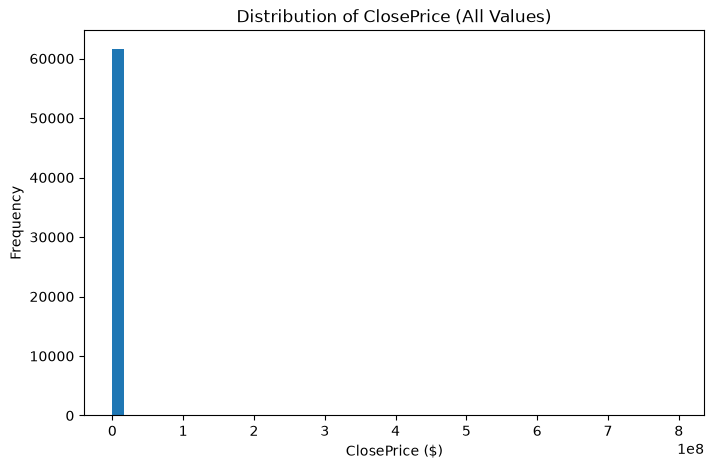

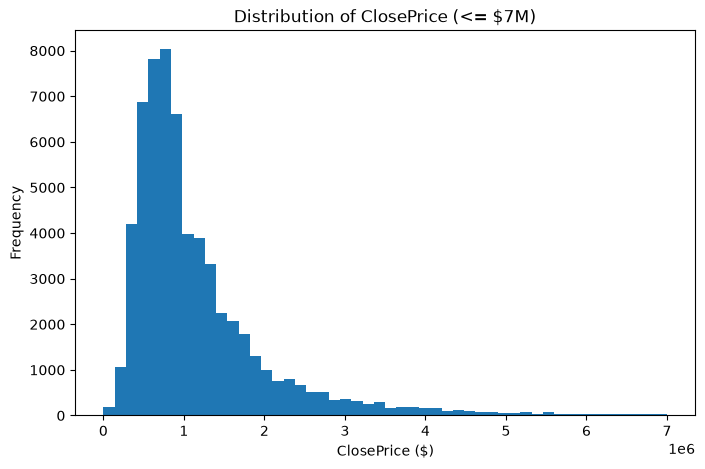

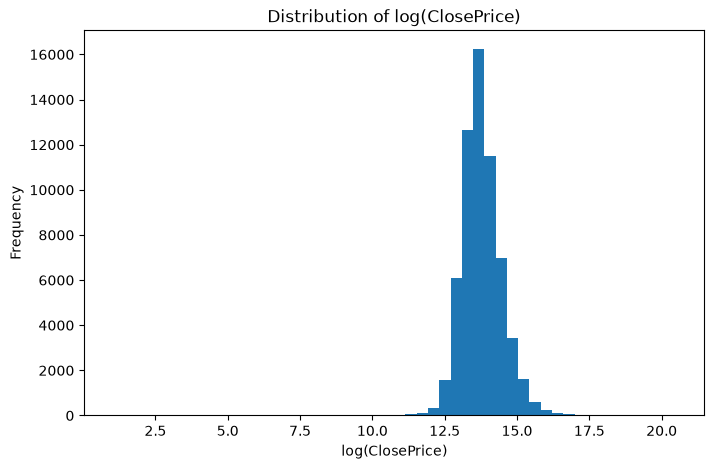

In [21]:
### Explore Distributions
## ClosePrice
# Defn: The amount of money paid by the purchaser to the seller for the property under the agreement

# Full Distribution of ClosePrice values
plt.figure(figsize=(8, 5))
plt.hist(key_df["ClosePrice"], bins=50)
plt.title("Distribution of ClosePrice (All Values)")
plt.xlabel("ClosePrice ($)")
plt.ylabel("Frequency")
plt.show()

# Zoomed in on ClosePrice values less than or equal to $7M for better visualization of the distribution
plt.figure(figsize=(8, 5))
plt.hist(key_df[key_df["ClosePrice"] <= 7_000_000]["ClosePrice"], bins=50)
plt.title("Distribution of ClosePrice (<= $7M)")
plt.xlabel("ClosePrice ($)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(key_df["ClosePrice"]), bins=50)
plt.title("Distribution of log(ClosePrice)")
plt.xlabel("log(ClosePrice)")
plt.ylabel("Frequency")
plt.show()

count    61697.000000
mean      2055.552918
std       1037.243701
min          0.000000
90%       3236.000000
95%       3838.000000
99%       5698.120000
max      23314.000000
Name: LivingArea, dtype: float64


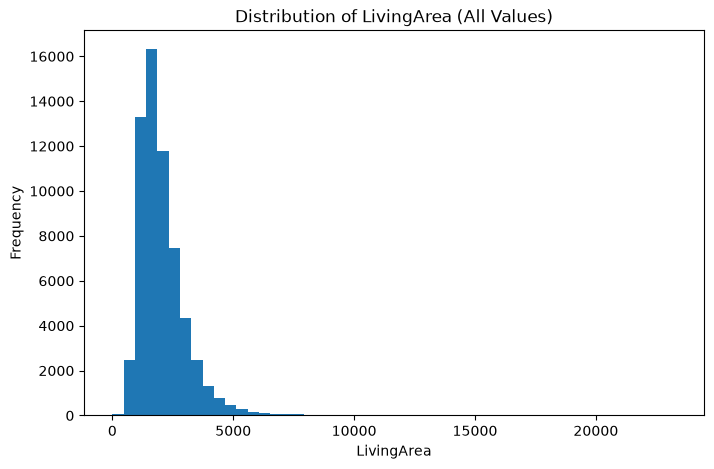

In [22]:
##Living Area
# Defn: The total livable area within the structure.

# Checking for outliers and percentiles in LivingArea values
print(df["LivingArea"].describe(percentiles=[0.90, 0.95, 0.99]))

# Full Distribution of LivingArea values
plt.figure(figsize=(8, 5))
plt.hist(df["LivingArea"], bins=50)
plt.title("Distribution of LivingArea (All Values)")
plt.xlabel("LivingArea")
plt.ylabel("Frequency")
plt.show()


count    61727.000000
mean         3.498437
std          0.966684
min          0.000000
90%          5.000000
95%          5.000000
99%          6.000000
max         22.000000
Name: BedroomsTotal, dtype: float64


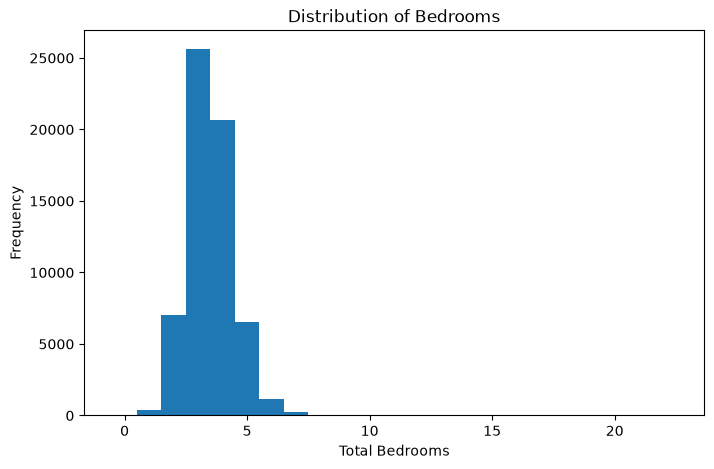

In [23]:
## Bedrooms = BedroomsTotal
# Defn: The total number of bedrooms in the property.

# Checking for outliers and percentiles in BedroomsTotal values
print(df["BedroomsTotal"].describe(percentiles=[0.90, 0.95, 0.99]))   

# Full Distribution of BedroomsTotal values
plt.figure(figsize=(8, 5))
plt.hist(df["BedroomsTotal"], bins=range(0, 24), align="left")
plt.title("Distribution of Bedrooms")
plt.xlabel("Total Bedrooms")
plt.ylabel("Frequency")
plt.show()


count    61726.000000
mean         2.644801
std          1.135026
min          0.000000
90%          4.000000
95%          5.000000
99%          6.000000
max         22.000000
Name: BathroomsTotalInteger, dtype: float64


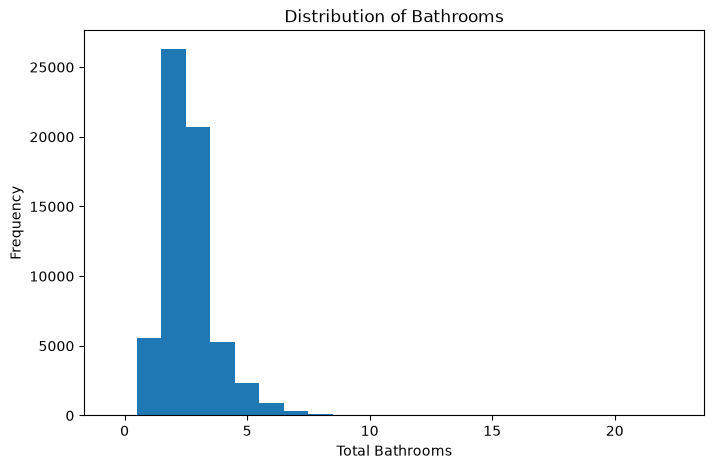

In [24]:
## Bathrooms = BathroomsTotalInteger
# Defn: The total number of bathrooms in the property.

# Checking for outliers and percentiles in BathroomsTotalInteger values
print(df["BathroomsTotalInteger"].describe(percentiles=[0.90, 0.95, 0.99]))  

# Full Distribution of BathroomsTotalInteger values
plt.figure(figsize=(8, 5))
plt.hist(df["BathroomsTotalInteger"], bins=range(0, 24), align="left")
plt.title("Distribution of Bathrooms")
plt.xlabel("Total Bathrooms")
plt.ylabel("Frequency")
plt.show()

count    60644.000000
mean        10.828569
std        544.530184
min          0.000000
90%          0.525180
95%          1.229085
99%          7.059700
max      60113.000000
Name: LotSizeAcres, dtype: float64


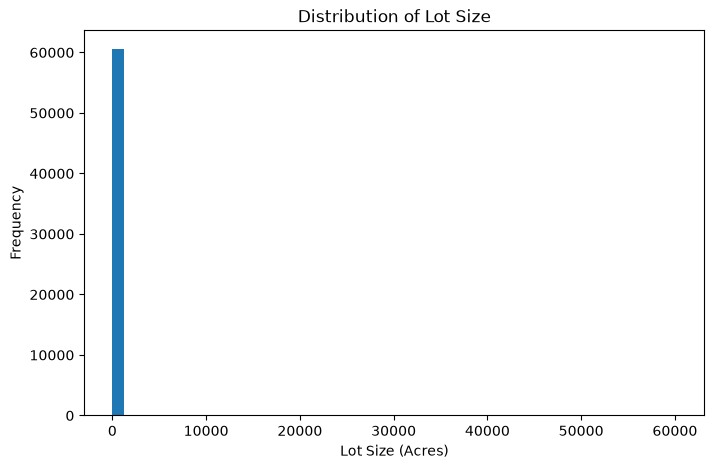

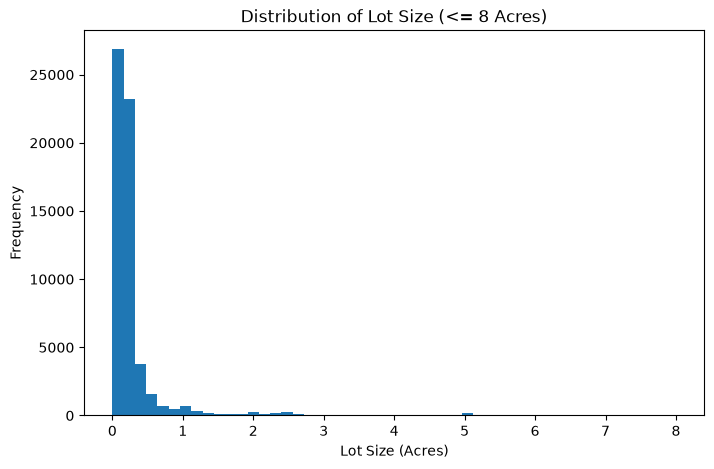

In [25]:
## LotSize = LotSizeAcres
# Defn: The total Acres of the lot.

# Checking for outliers and percentiles in LotSizeAcres values
print(df["LotSizeAcres"].describe(percentiles=[0.90, 0.95, 0.99]))   

# Full Distribution of LotSizeAcres values
plt.figure(figsize=(8, 5))
plt.hist(df["LotSizeAcres"], bins=50)
plt.title("Distribution of Lot Size")
plt.xlabel("Lot Size (Acres)")
plt.ylabel("Frequency")
plt.show()

# Zoomed in on LotSizeAcres values less than or equal to 8 Acres for better visualization of the distribution
plt.figure(figsize=(8, 5))
plt.hist(df[df["LotSizeAcres"] <= 8]["LotSizeAcres"], bins=50)
plt.title("Distribution of Lot Size (<= 8 Acres)")
plt.xlabel("Lot Size (Acres)")
plt.ylabel("Frequency")
plt.show()